Libraries loaded successfully
Test set       : (384, 21)
y_pred range   : -0.2489 ~ 4.6733

Percentile cutoffs (predicted DSR):
  Top 10%: DSR >= 0.7318  (n=39)
  Top 20%: DSR >= 0.3938  (n=77)
  Top 30%: DSR >= 0.2532  (n=115)

=== Part A: Policy Effect by Percentile Group ===

  [Top 10%]  cutoff=0.7318  n=39
    A-20 (Debt -20%)      : 0.1205 [0.0649, 0.1783]  Yes
    A-40 (Debt -40%)      : 0.2432 [0.1397, 0.3482]  Yes
    A-60 (Debt -60%)      : 0.4188 [0.2746, 0.5534]  Yes
    B-20 (Income +20%)    : 0.4755 [0.2933, 0.6428]  Yes
    B-40 (Income +40%)    : 0.6767 [0.4391, 0.9027]  Yes
    B-60 (Income +60%)    : 0.8650 [0.5592, 1.1439]  Yes
    C (A-40+B-40)         : 0.8641 [0.5865, 1.1235]  Yes

  [Top 20%]  cutoff=0.3938  n=77
    A-20 (Debt -20%)      : 0.0831 [0.052, 0.1188]  Yes
    A-40 (Debt -40%)      : 0.1674 [0.1162, 0.2332]  Yes
    A-60 (Debt -60%)      : 0.2693 [0.1947, 0.3494]  Yes
    B-20 (Income +20%)    : 0.3205 [0.1975, 0.4508]  Yes
    B-40 (Income +40%)    :

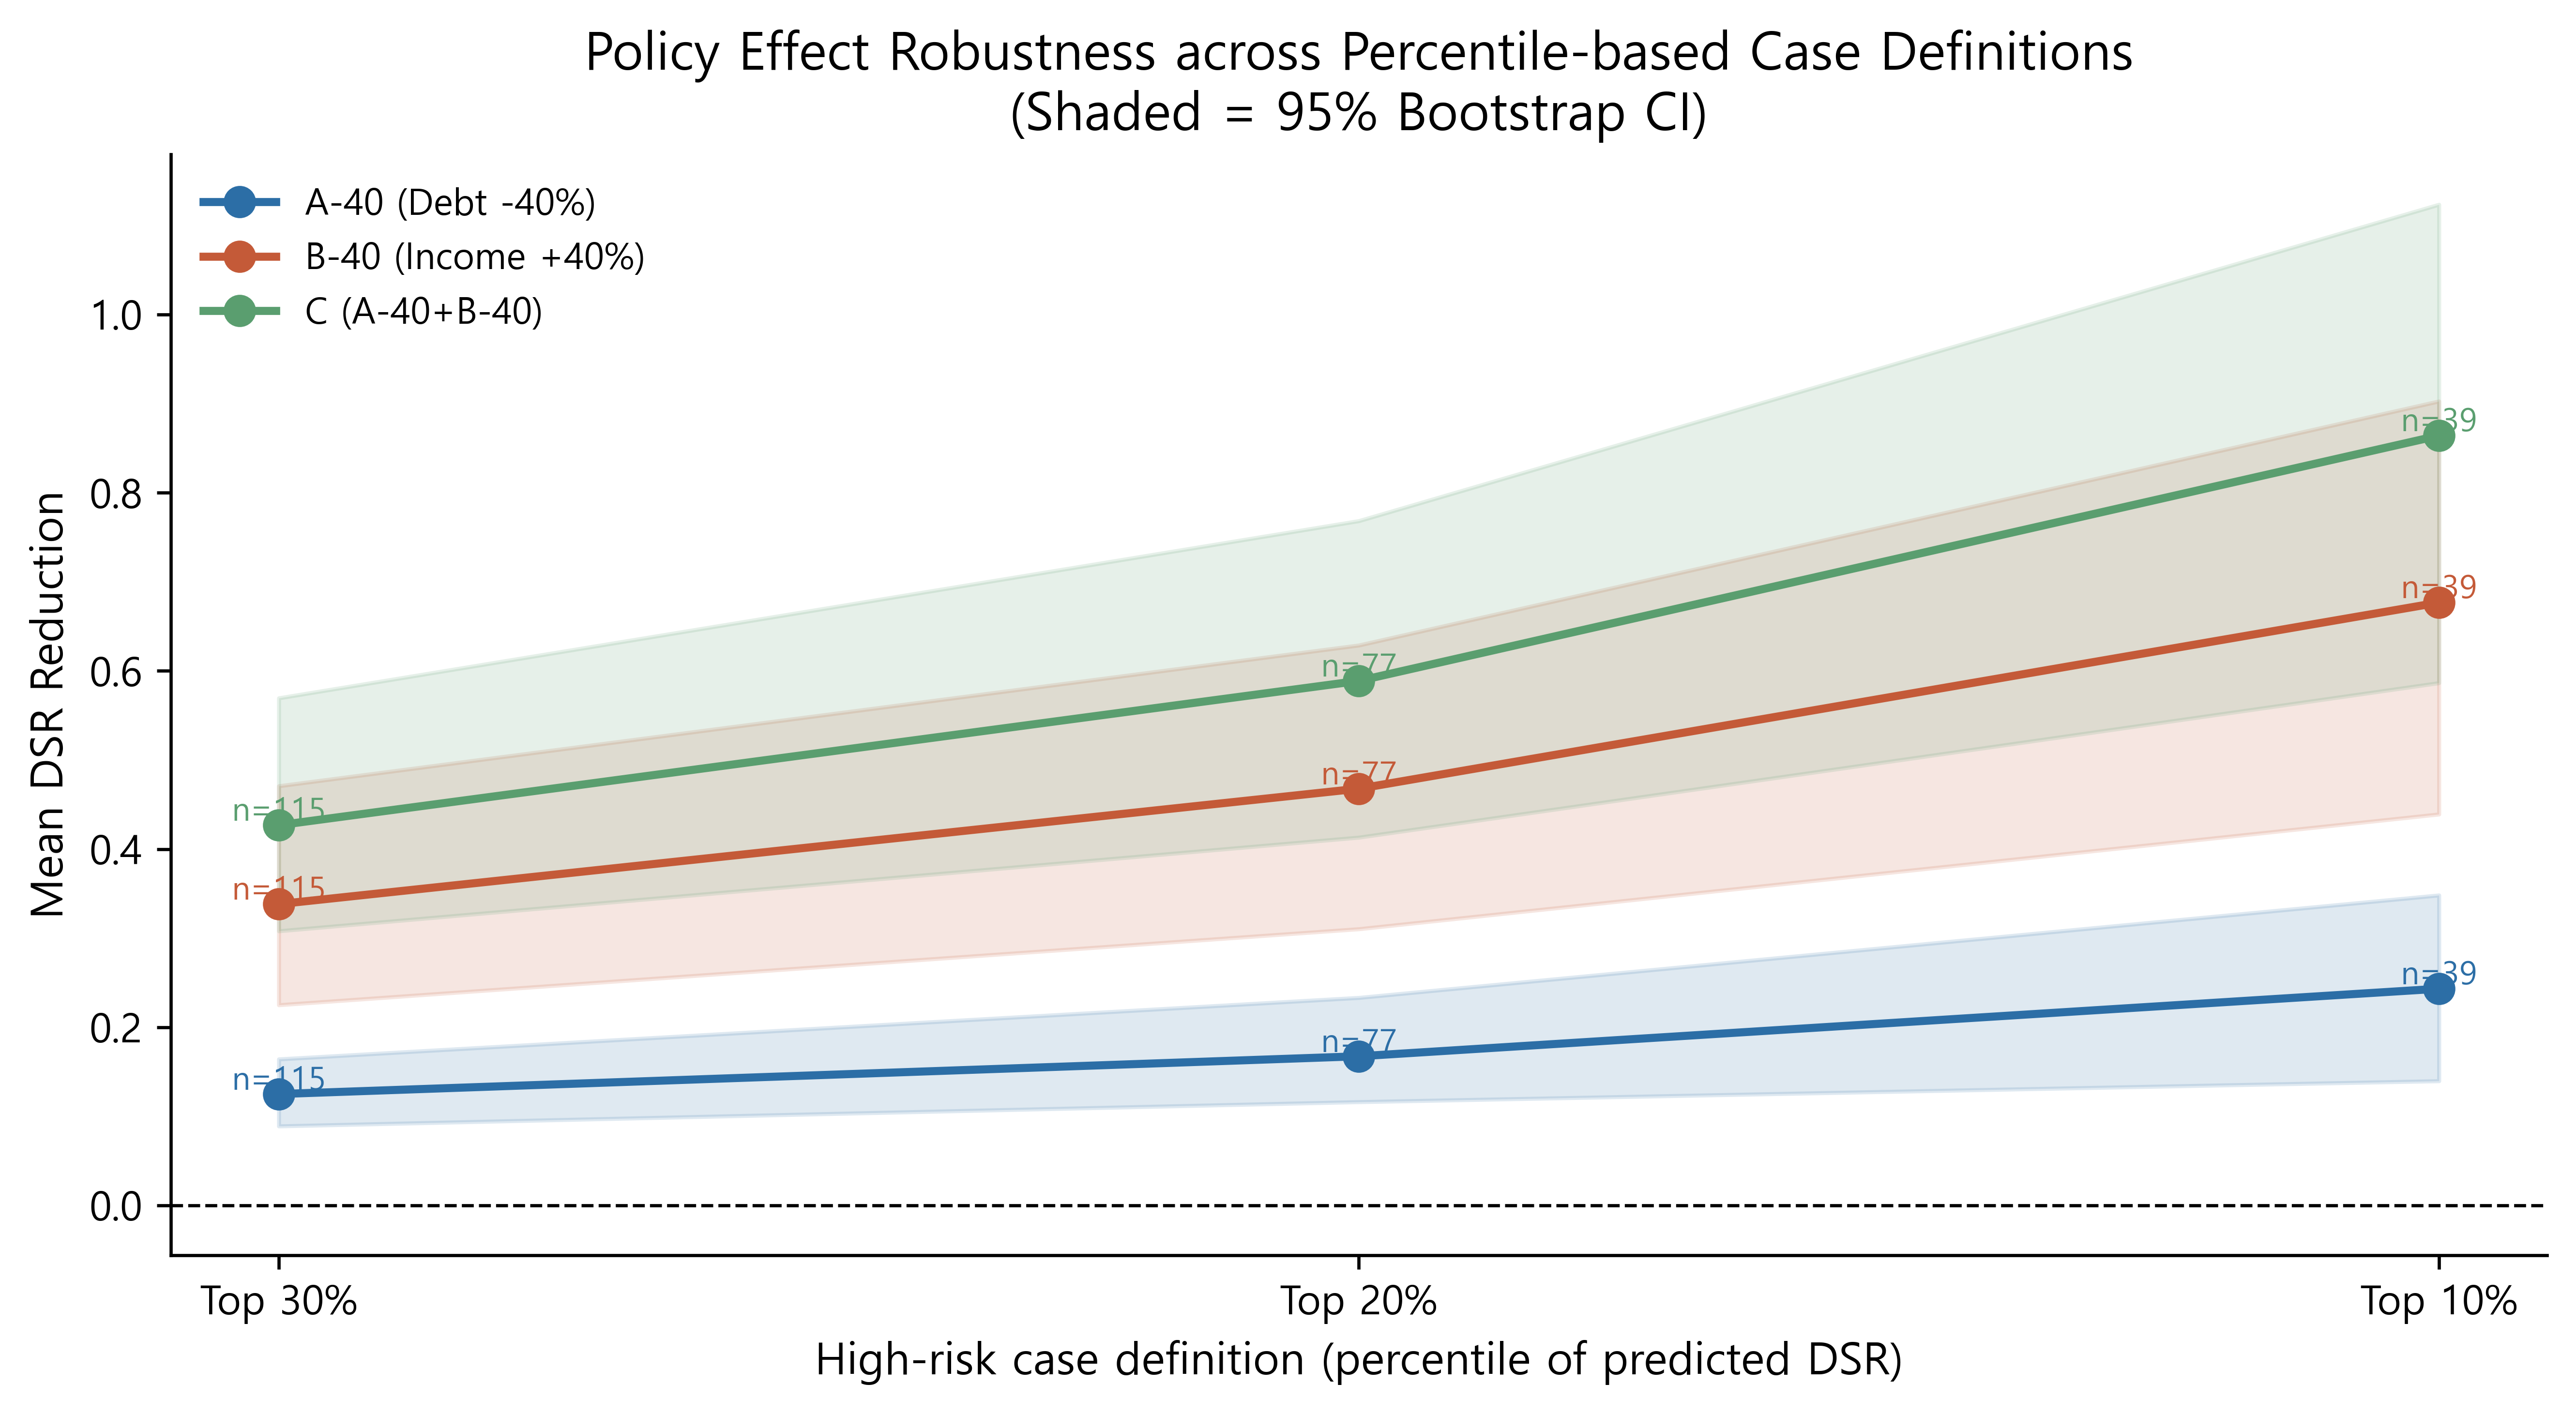

Saved -> outputs/38_policy_pct_robustness_reg.png

=== Part B: Subgroup Heterogeneity by Percentile Group (Policy C) ===
  Top 10% | Employed     n=5  DSR red=0.0521  CI=[-0.0172, 0.1135]  
  Top 10% | Unemployed   n=5  DSR red=0.4118  CI=[0.2754, 0.5203]  *
  Top 10% | Inactive     n=2  DSR red=1.2386  CI=[N/A, N/A]  
  Top 20% | Employed     n=26  DSR red=0.1413  CI=[0.1052, 0.1804]  *
  Top 20% | Unemployed   n=12  DSR red=0.2744  CI=[0.1552, 0.3821]  *
  Top 20% | Inactive     n=3  DSR red=0.9104  CI=[N/A, N/A]  
  Top 30% | Employed     n=44  DSR red=0.1012  CI=[0.073, 0.1297]  *
  Top 30% | Unemployed   n=23  DSR red=0.1894  CI=[0.106, 0.2659]  *
  Top 30% | Inactive     n=4  DSR red=0.7318  CI=[N/A, N/A]  

Saved -> outputs/robustness_subgroup_pct_reg.csv


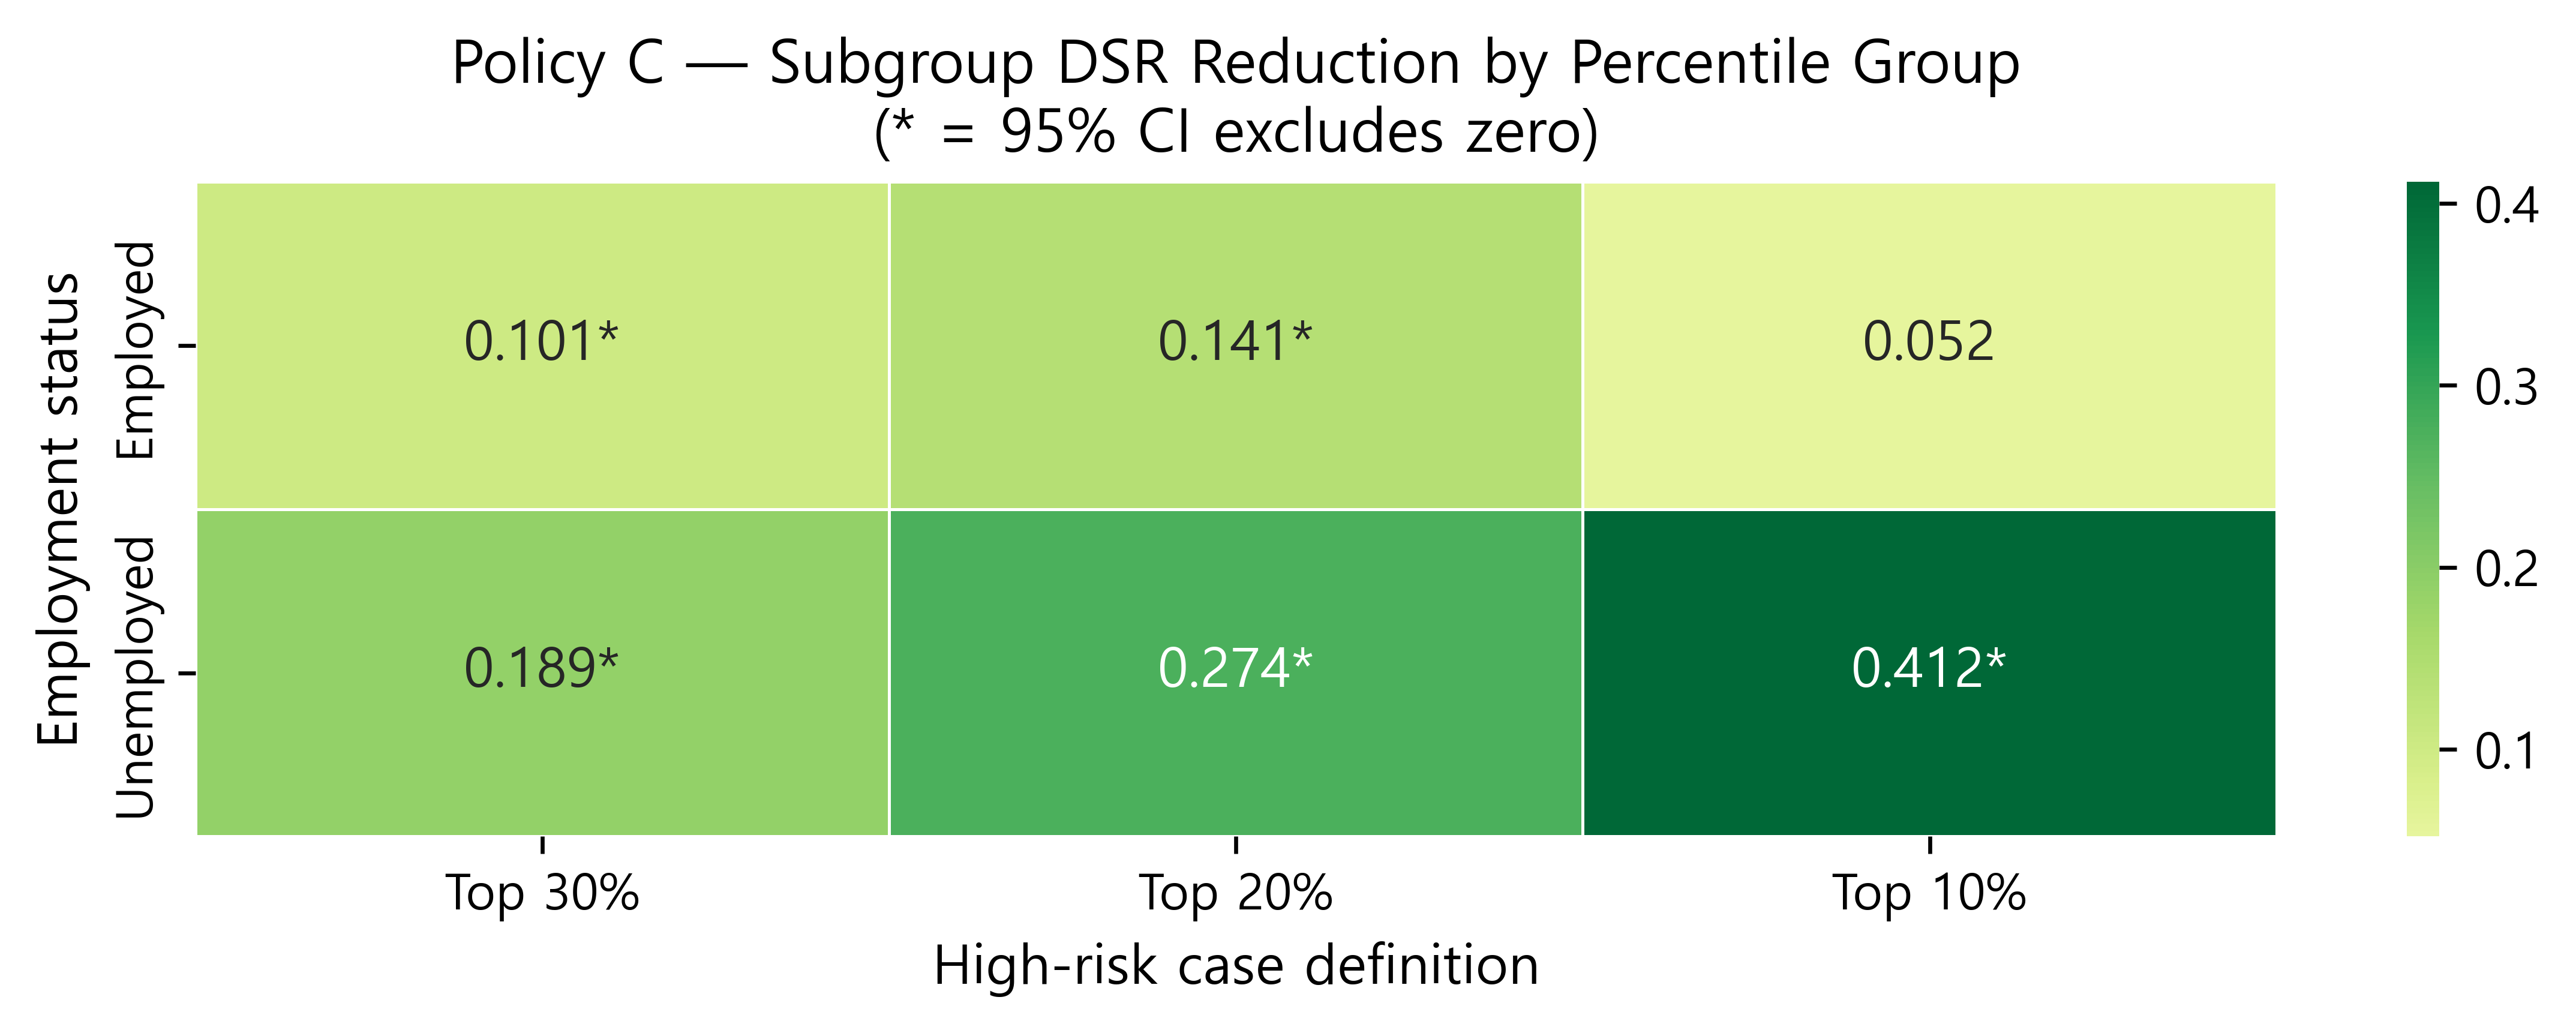

Saved -> outputs/39_subgroup_pct_heatmap_reg.png

=== Part C: CF Feature Stability across Percentile Groups ===


100%|██████████| 1/1 [00:00<00:00,  2.27it/s]


  Top 10%: top5 = ['h19_pers_income2', 'employment_status', 'housing_tenure', 'age', 'housing_debt_balance']


100%|██████████| 1/1 [00:00<00:00,  1.72it/s]


  Top 20%: top5 = ['h19_pers_income2', 'h19_pers_income1', 'employment_status', 'debt_financial', 'age']


100%|██████████| 1/1 [00:00<00:00,  2.30it/s]


  Top 30%: top5 = ['housing_tenure', 'h19_pers_income2', 'employment_status', 'housing_debt_balance', 'h19_pers_income4']
Percentile group  N cases used                                                                              Top 5 features
         Top 10%            10              h19_pers_income2, employment_status, housing_tenure, age, housing_debt_balance
         Top 20%            10                  h19_pers_income2, h19_pers_income1, employment_status, debt_financial, age
         Top 30%            10 housing_tenure, h19_pers_income2, employment_status, housing_debt_balance, h19_pers_income4


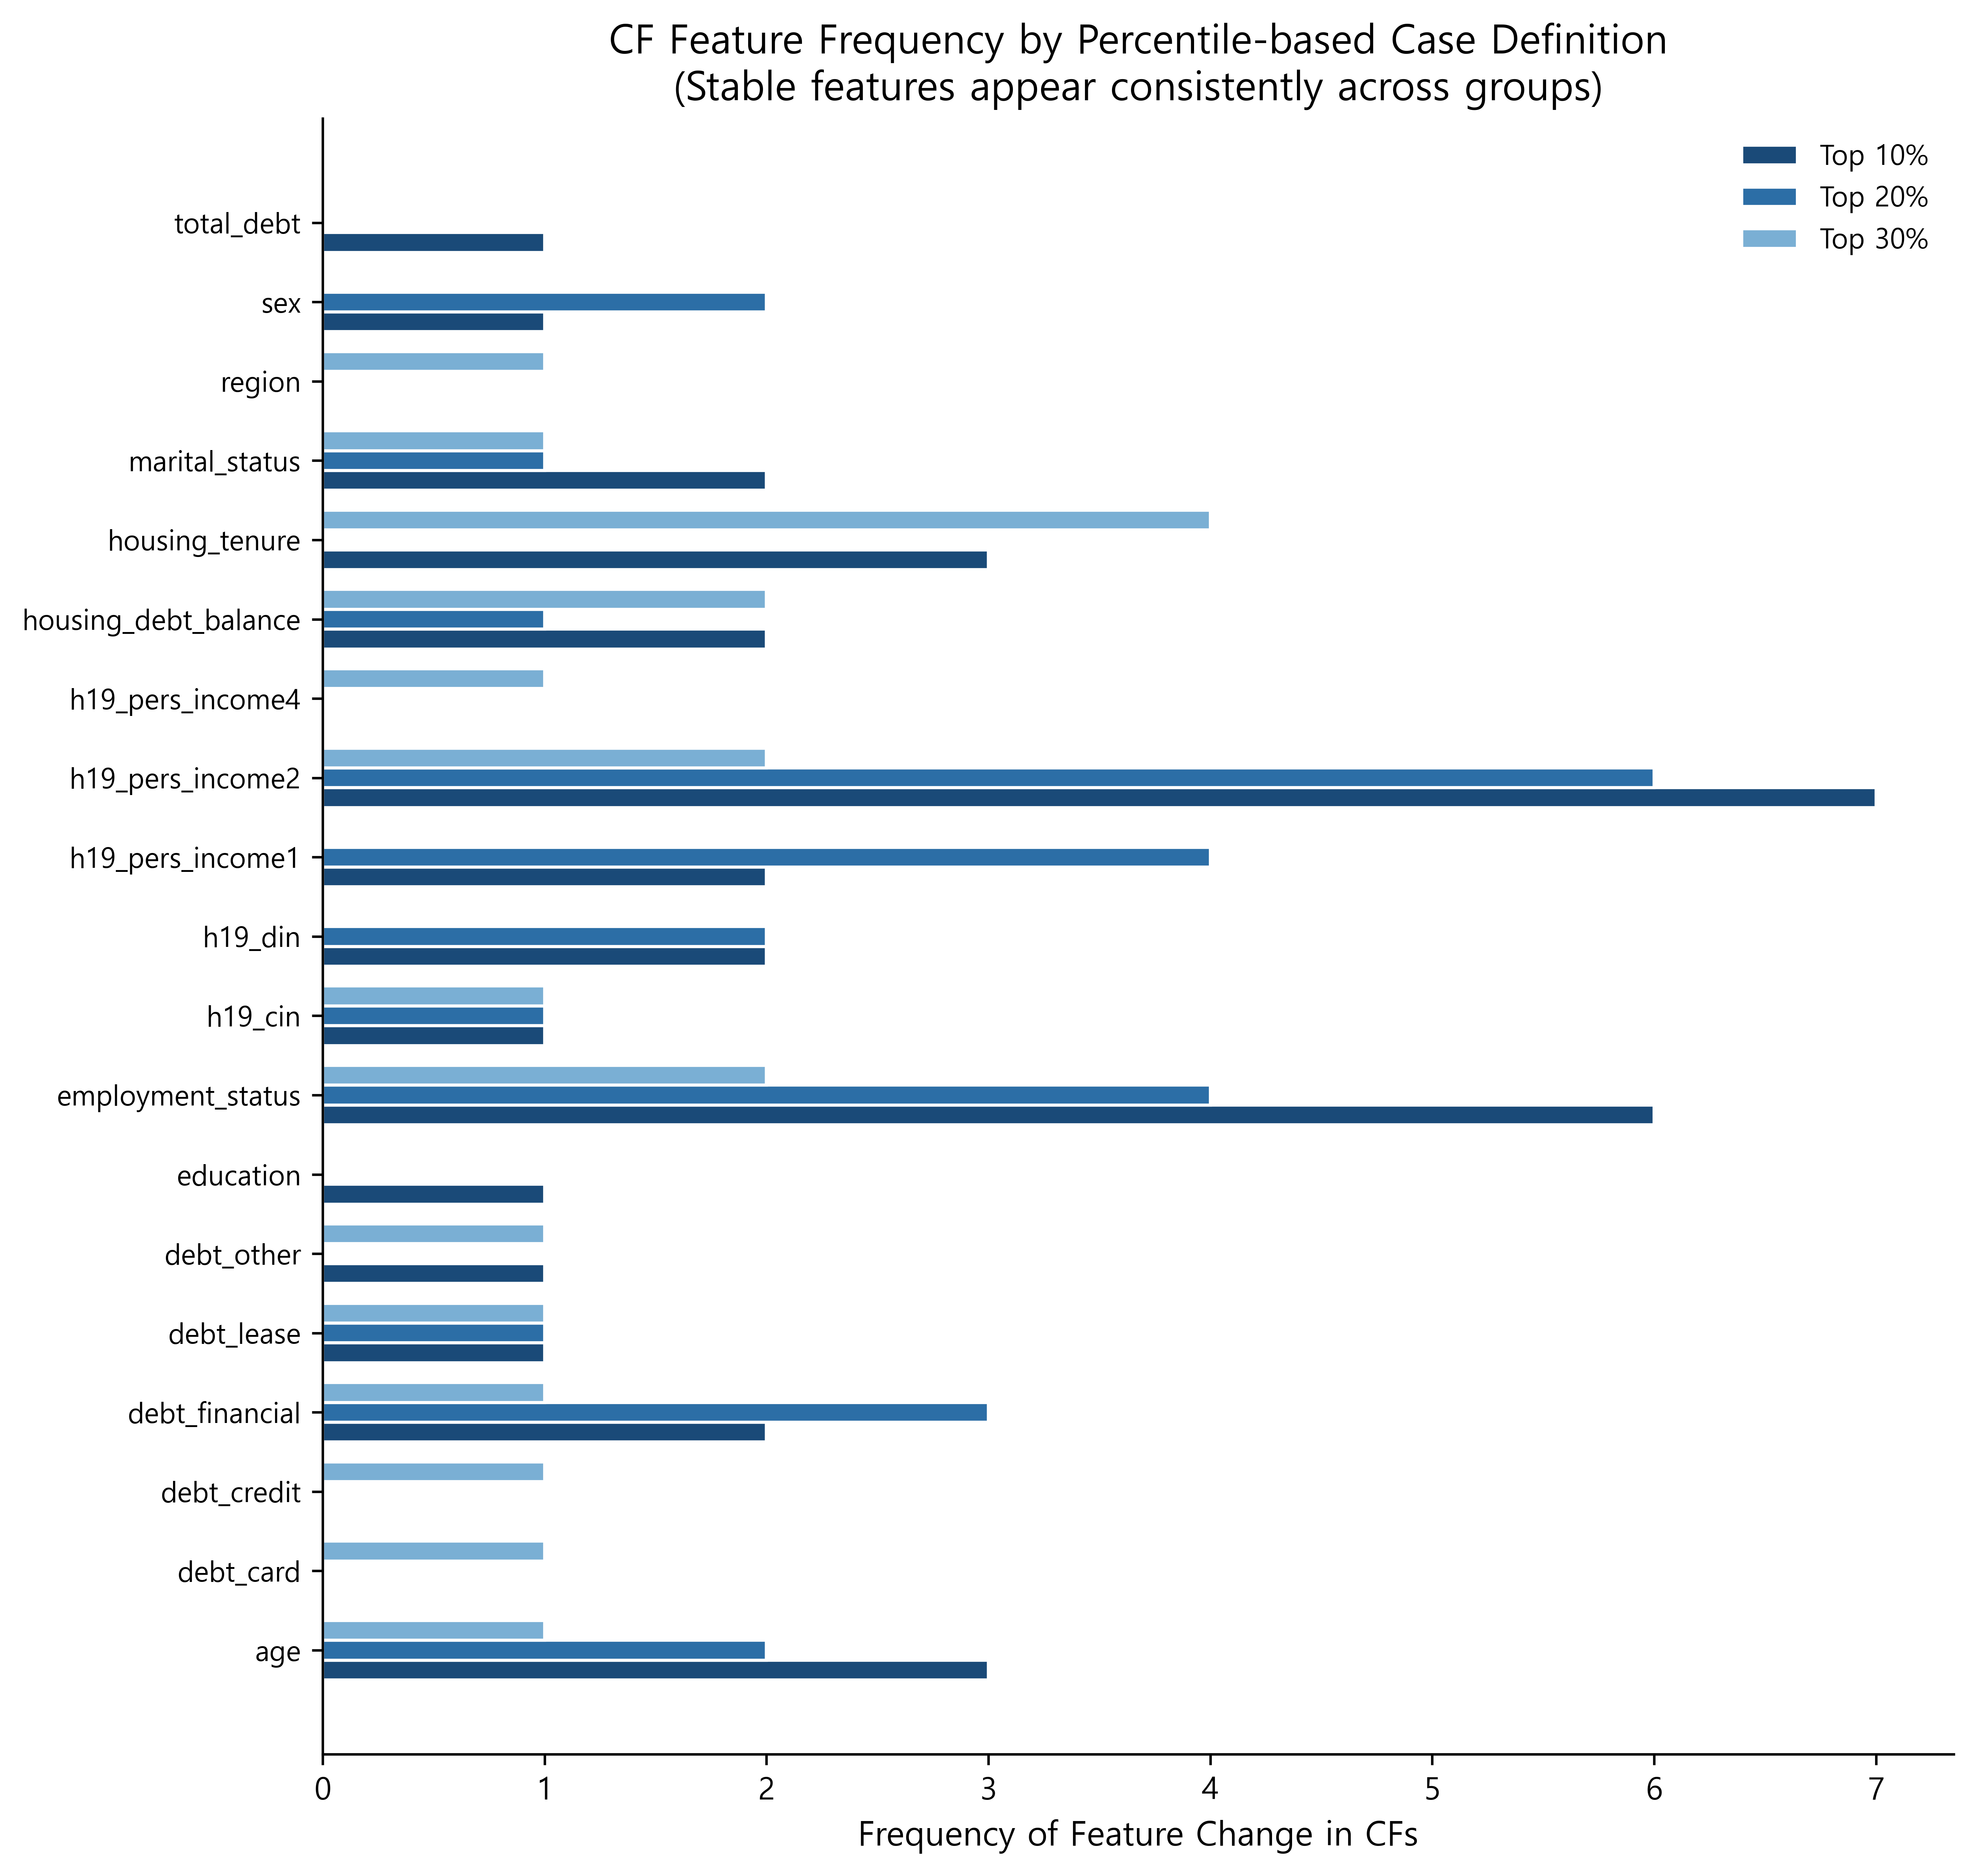

Saved -> outputs/40_cf_feature_pct_stability_reg.png

=== Robustness Summary ===

[Part A — Policy Effect]
  A-40 (Debt -40%)      : significant in 3/3 percentile groups
  B-40 (Income +40%)    : significant in 3/3 percentile groups
  C (A-40+B-40)         : significant in 3/3 percentile groups

[Part B — Subgroup Heterogeneity Direction]
  Employed    : positive direction in 3/3 groups, significant in 2/3 groups
  Unemployed  : positive direction in 3/3 groups, significant in 3/3 groups

[Part C — CF Feature Stability]
  Features stable across all 3 groups: ['employment_status', 'h19_pers_income2']
  Features stable in >= 2/3 groups   : ['age', 'employment_status', 'h19_pers_income2', 'housing_debt_balance', 'housing_tenure']

Saved -> outputs/robustness_cf_features_pct_reg.csv


In [1]:
# ═══════════════════════════════════════════════════════════════
# Notebook  : 11_dsr_percentile_robustness_regression
# Project   : XAI-Driven DSR Prediction Framework for Youth Debt Crisis
# Purpose   : Robustness check: do policy effects hold across different
#             high-risk case definitions (top 10%, 20%, 30% predicted DSR)?
#             Replaces fixed DSR>=0.4 threshold with percentile-based
#             case selection; checks stability of:
#             (A) mean DSR reduction per policy
#             (B) subgroup heterogeneity direction
#             (C) most frequently changed CF features
# Data      : X_test_reg.csv, y_test_reg.csv, model_lgbm_reg.pkl,
#             dice_cf_summary_reg.csv
# Author    :
# ═══════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────
# Cell 1 | Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
import joblib
import dice_ml
from dice_ml import Dice
from collections import Counter

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 600
matplotlib.rcParams['savefig.dpi'] = 600
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.titlesize'] = 13
matplotlib.rcParams['axes.labelsize'] = 11
matplotlib.rcParams['xtick.labelsize'] = 10
matplotlib.rcParams['ytick.labelsize'] = 10
matplotlib.rcParams['lines.linewidth'] = 1.5
matplotlib.rcParams['axes.linewidth'] = 0.8

SAVE_KW    = dict(dpi=600, bbox_inches='tight', format='png')
N_BOOT     = 1000
EMP_LABELS = {1: 'Employed', 2: 'Unemployed', 3: 'Inactive'}

print("Libraries loaded successfully")


# ─────────────────────────────────────────────
# Cell 2 | Load model & data
# ─────────────────────────────────────────────
lgbm    = joblib.load('../outputs/model_lgbm_reg.pkl')
X_test  = pd.read_csv('../data/X_test_reg.csv')
y_test  = pd.read_csv('../data/y_test_reg.csv').squeeze()
X_train = pd.read_csv('../data/X_train_reg.csv')
y_train = pd.read_csv('../data/y_train_reg.csv').squeeze()

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)
y_pred_r = lgbm.predict(X_test_r.values)

feature_names = X_train.columns.tolist()

# Percentile cutoffs for high-risk case definition
PERCENTILES = {
    'Top 10%': np.percentile(y_pred_r, 90),
    'Top 20%': np.percentile(y_pred_r, 80),
    'Top 30%': np.percentile(y_pred_r, 70),
}

print(f"Test set       : {X_test_r.shape}")
print(f"y_pred range   : {y_pred_r.min():.4f} ~ {y_pred_r.max():.4f}")
print(f"\nPercentile cutoffs (predicted DSR):")
for label, cutoff in PERCENTILES.items():
    n = (y_pred_r >= cutoff).sum()
    print(f"  {label}: DSR >= {cutoff:.4f}  (n={n})")


# ─────────────────────────────────────────────
# Cell 3 | Policy simulation helper
# ─────────────────────────────────────────────
POLICIES = {
    'A-20 (Debt -20%)'  : {'debt_financial'  : -0.20},
    'A-40 (Debt -40%)'  : {'debt_financial'  : -0.40},
    'A-60 (Debt -60%)'  : {'debt_financial'  : -0.60},
    'B-20 (Income +20%)': {'h19_pers_income2': +0.20},
    'B-40 (Income +40%)': {'h19_pers_income2': +0.40},
    'B-60 (Income +60%)': {'h19_pers_income2': +0.60},
    'C (A-40+B-40)'     : {'debt_financial'  : -0.40,
                            'h19_pers_income2': +0.40},
}

def simulate(X_base, changes, X_ref):
    """Apply policy changes; income increase scaled to X_ref mean."""
    X_sim = X_base.copy()
    for feat, delta in changes.items():
        if feat not in X_sim.columns:
            continue
        if delta < 0:
            X_sim[feat] = (X_sim[feat] * (1 + delta)).clip(lower=0)
        else:
            col_mean    = X_ref[feat].mean()
            X_sim[feat] = X_sim[feat] + col_mean * delta
    return lgbm.predict(X_sim.values)

def boot_mean_ci(values, n_boot=N_BOOT, seed=42):
    rng  = np.random.default_rng(seed)
    n    = len(values)
    if n < 5:
        return np.nan, np.nan
    boot = np.array([values[rng.integers(0, n, n)].mean()
                     for _ in range(n_boot)])
    return np.percentile(boot, 2.5), np.percentile(boot, 97.5)


# ─────────────────────────────────────────────
# Cell 4 | Part A: Policy effect by percentile group
# Mean DSR reduction with 95% CI for each cutoff
# ─────────────────────────────────────────────
print("\n=== Part A: Policy Effect by Percentile Group ===")
partA_rows = []

for pct_label, cutoff in PERCENTILES.items():
    mask     = y_pred_r >= cutoff
    X_grp    = X_test_r[mask].reset_index(drop=True)
    pred_grp = y_pred_r[mask]
    n_grp    = mask.sum()

    for pol_name, changes in POLICIES.items():
        sim_preds = simulate(X_grp, changes, X_grp)
        red       = pred_grp - sim_preds
        point     = red.mean()
        lo, hi    = boot_mean_ci(red)

        partA_rows.append({
            'Percentile group'  : pct_label,
            'Cutoff (pred DSR)' : round(cutoff, 4),
            'N'                 : int(n_grp),
            'Policy'            : pol_name,
            'Mean DSR reduction': round(point, 4),
            'CI lower (95%)'    : round(lo, 4) if not np.isnan(lo) else np.nan,
            'CI upper (95%)'    : round(hi, 4) if not np.isnan(hi) else np.nan,
            'Significant'       : ('Yes' if (not np.isnan(lo) and lo > 0)
                                   else ('N/A' if np.isnan(lo) else 'No')),
        })

    print(f"\n  [{pct_label}]  cutoff={cutoff:.4f}  n={n_grp}")
    sub = [r for r in partA_rows if r['Percentile group'] == pct_label]
    for r in sub:
        sig = r['Significant']
        print(f"    {r['Policy']:<22}: {r['Mean DSR reduction']:.4f} "
              f"[{r['CI lower (95%)']}, {r['CI upper (95%)']}]  {sig}")

partA_df = pd.DataFrame(partA_rows)
partA_df.to_csv('../outputs/robustness_policy_pct_reg.csv',
                index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/robustness_policy_pct_reg.csv")


# ─────────────────────────────────────────────
# Cell 5 | Visualize Part A: line plot across percentile groups
# ─────────────────────────────────────────────
focus_pols = ['A-40 (Debt -40%)', 'B-40 (Income +40%)', 'C (A-40+B-40)']
pol_colors = ['#2c6ea6', '#c45a38', '#5a9e6f']
pct_order  = ['Top 30%', 'Top 20%', 'Top 10%']

fig, ax = plt.subplots(figsize=(9, 5))

for pol, color in zip(focus_pols, pol_colors):
    sub    = partA_df[partA_df['Policy'] == pol].set_index('Percentile group')
    points = [sub.loc[p, 'Mean DSR reduction'] for p in pct_order]
    los    = [sub.loc[p, 'CI lower (95%)'] for p in pct_order]
    his    = [sub.loc[p, 'CI upper (95%)'] for p in pct_order]
    ns     = [sub.loc[p, 'N'] for p in pct_order]

    ax.plot(pct_order, points, color=color, lw=2,
            marker='o', markersize=7, label=pol)
    ax.fill_between(pct_order,
                    [l if not np.isnan(l) else p
                     for l, p in zip(los, points)],
                    [h if not np.isnan(h) else p
                     for h, p in zip(his, points)],
                    color=color, alpha=0.15)

    for i, (p, n) in enumerate(zip(points, ns)):
        ax.text(i, p + 0.005, f'n={n}', ha='center', fontsize=8, color=color)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('High-risk case definition (percentile of predicted DSR)')
ax.set_ylabel('Mean DSR Reduction')
ax.set_title('Policy Effect Robustness across Percentile-based Case Definitions\n'
             '(Shaded = 95% Bootstrap CI)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/38_policy_pct_robustness_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/38_policy_pct_robustness_reg.png")


# ─────────────────────────────────────────────
# Cell 6 | Part B: Subgroup heterogeneity by percentile group
# Does Employed vs Unemployed direction hold across cutoffs?
# ─────────────────────────────────────────────
print("\n=== Part B: Subgroup Heterogeneity by Percentile Group (Policy C) ===")
partB_rows = []

for pct_label, cutoff in PERCENTILES.items():
    mask  = y_pred_r >= cutoff
    X_grp = X_test_r[mask].reset_index(drop=True)
    pred_grp = y_pred_r[mask]
    sim_grp  = simulate(X_grp, POLICIES['C (A-40+B-40)'], X_grp)
    red_grp  = pred_grp - sim_grp

    for emp_val, emp_label in EMP_LABELS.items():
        emp_mask = (X_grp['employment_status'] == emp_val).values
        n_sub    = emp_mask.sum()
        if n_sub == 0:
            continue
        sub_red = red_grp[emp_mask]
        point   = sub_red.mean()
        lo, hi  = boot_mean_ci(sub_red)

        partB_rows.append({
            'Percentile group'  : pct_label,
            'N (group)'         : int(mask.sum()),
            'Subgroup'          : emp_label,
            'N (subgroup)'      : int(n_sub),
            'Mean DSR reduction': round(point, 4),
            'CI lower (95%)'    : round(lo, 4) if not np.isnan(lo) else np.nan,
            'CI upper (95%)'    : round(hi, 4) if not np.isnan(hi) else np.nan,
            'Significant'       : ('Yes' if (not np.isnan(lo) and lo > 0)
                                   else ('N/A' if np.isnan(lo) else 'No')),
        })
        print(f"  {pct_label} | {emp_label:<12} n={n_sub}"
              f"  DSR red={point:.4f}"
              f"  CI=[{round(lo,4) if not np.isnan(lo) else 'N/A'},"
              f" {round(hi,4) if not np.isnan(hi) else 'N/A'}]"
              f"  {('*' if (not np.isnan(lo) and lo > 0) else '')}")

partB_df = pd.DataFrame(partB_rows)
partB_df.to_csv('../outputs/robustness_subgroup_pct_reg.csv',
                index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/robustness_subgroup_pct_reg.csv")


# ─────────────────────────────────────────────
# Cell 7 | Visualize Part B: heatmap
# Employed vs Unemployed DSR reduction across percentile groups
# ─────────────────────────────────────────────
pivot_b = partB_df[partB_df['Subgroup'].isin(['Employed', 'Unemployed'])]\
          .pivot(index='Subgroup', columns='Percentile group',
                 values='Mean DSR reduction')
pivot_b = pivot_b[['Top 30%', 'Top 20%', 'Top 10%']]

# Significance annotation
sig_b = partB_df[partB_df['Subgroup'].isin(['Employed', 'Unemployed'])]\
        .pivot(index='Subgroup', columns='Percentile group',
               values='Significant')
sig_b = sig_b[['Top 30%', 'Top 20%', 'Top 10%']]

annot_b = pivot_b.copy().astype(str)
for r in annot_b.index:
    for c in annot_b.columns:
        val = pivot_b.loc[r, c]
        sig = sig_b.loc[r, c] if c in sig_b.columns else ''
        star = '*' if sig == 'Yes' else ''
        annot_b.loc[r, c] = (f"{val:.3f}{star}"
                              if not np.isnan(val) else 'N/A')

import seaborn as sns
fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(pivot_b, annot=annot_b, fmt='', cmap='RdYlGn',
            center=0, linewidths=0.4, linecolor='white',
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Policy C — Subgroup DSR Reduction by Percentile Group\n'
             '(* = 95% CI excludes zero)', fontsize=12)
ax.set_xlabel('High-risk case definition', fontsize=11)
ax.set_ylabel('Employment status', fontsize=11)
plt.tight_layout()
plt.savefig('../outputs/39_subgroup_pct_heatmap_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/39_subgroup_pct_heatmap_reg.png")


# ─────────────────────────────────────────────
# Cell 8 | Part C: CF feature stability across percentile groups
# Re-run DiCE for each percentile group; compare top-5 features
# ─────────────────────────────────────────────
print("\n=== Part C: CF Feature Stability across Percentile Groups ===")

# Build DiCE interface once
X_train_num         = X_train.copy().astype(float)
y_train_num         = y_train.copy().astype(float)
df_train_dice       = X_train_num.copy()
df_train_dice['dsr']= y_train_num.values

data_iface  = dice_ml.Data(
    dataframe           = df_train_dice,
    continuous_features = feature_names,
    outcome_name        = 'dsr'
)
model_iface = dice_ml.Model(
    model=lgbm, backend='sklearn', model_type='regressor')
dice_exp    = Dice(data_iface, model_iface, method='random')

partC_rows  = []
freq_by_pct = {}

for pct_label, cutoff in PERCENTILES.items():
    mask     = y_pred_r >= cutoff
    idx_list = np.where(mask)[0][:10]  # up to 10 cases per group
    changed_all = []

    for idx in idx_list:
        instance = X_test_r.iloc[[idx]].copy().astype(float)
        try:
            cf_obj   = dice_exp.generate_counterfactuals(
                instance, total_CFs=1,
                desired_range=[0.0, 0.2])
            cf_feats = cf_obj.cf_examples_list[0].final_cfs_df
            if cf_feats is None or len(cf_feats) == 0:
                continue
            cf_feats  = cf_feats.drop(columns=['dsr'], errors='ignore')
            diff_mask = (instance.iloc[0].values != cf_feats.iloc[0].values)
            changed   = [feature_names[k] for k in range(len(feature_names))
                         if k < len(diff_mask) and diff_mask[k]]
            changed_all.extend(changed)
        except Exception:
            continue

    freq      = Counter(changed_all)
    top5      = [f for f, _ in freq.most_common(5)]
    freq_by_pct[pct_label] = freq

    partC_rows.append({
        'Percentile group': pct_label,
        'N cases used'    : len(idx_list),
        'Top 5 features'  : ', '.join(top5),
    })
    print(f"  {pct_label}: top5 = {top5}")

partC_df = pd.DataFrame(partC_rows)
print(partC_df.to_string(index=False))


# ─────────────────────────────────────────────
# Cell 9 | Visualize Part C: feature frequency comparison
# ─────────────────────────────────────────────
all_feats_c = sorted(set(f for freq in freq_by_pct.values() for f in freq))
pct_colors  = {'Top 10%': '#1a4a78', 'Top 20%': '#2c6ea6', 'Top 30%': '#7aafd4'}

fig, ax = plt.subplots(figsize=(9, max(4, len(all_feats_c) * 0.45)))
y_pos   = np.arange(len(all_feats_c))
width   = 0.25

for i, (pct_label, color) in enumerate(pct_colors.items()):
    counts = [freq_by_pct[pct_label].get(f, 0) for f in all_feats_c]
    offset = (i - 1) * width
    ax.barh(y_pos + offset, counts, height=width,
            color=color, label=pct_label, edgecolor='white')

ax.set_yticks(y_pos)
ax.set_yticklabels(all_feats_c, fontsize=9)
ax.set_xlabel('Frequency of Feature Change in CFs')
ax.set_title('CF Feature Frequency by Percentile-based Case Definition\n'
             '(Stable features appear consistently across groups)')
ax.legend(frameon=False, fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/40_cf_feature_pct_stability_reg.png', **SAVE_KW)
plt.show()
print("Saved -> outputs/40_cf_feature_pct_stability_reg.png")


# ─────────────────────────────────────────────
# Cell 10 | Summary: robustness verdict
# ─────────────────────────────────────────────
print("\n=== Robustness Summary ===")

print("\n[Part A — Policy Effect]")
for pol in focus_pols:
    sub = partA_df[partA_df['Policy'] == pol]
    sig_counts = (sub['Significant'] == 'Yes').sum()
    print(f"  {pol:<22}: significant in {sig_counts}/3 percentile groups")

print("\n[Part B — Subgroup Heterogeneity Direction]")
for emp_label in ['Employed', 'Unemployed']:
    sub = partB_df[partB_df['Subgroup'] == emp_label]
    directions = (sub['Mean DSR reduction'] > 0).sum()
    sig_counts = (sub['Significant'] == 'Yes').sum()
    print(f"  {emp_label:<12}: positive direction in {directions}/3 groups, "
          f"significant in {sig_counts}/3 groups")

print("\n[Part C — CF Feature Stability]")
# Features appearing in top-5 of all 3 groups
stable_feats = [f for f in all_feats_c
                if all(f in [x for x, _ in freq_by_pct[p].most_common(5)]
                       for p in PERCENTILES)]
print(f"  Features stable across all 3 groups: {stable_feats if stable_feats else 'None in strict top-5'}")

# Features in top-5 of at least 2 groups
moderate_feats = [f for f in all_feats_c
                  if sum(f in [x for x, _ in freq_by_pct[p].most_common(5)]
                         for p in PERCENTILES) >= 2]
print(f"  Features stable in >= 2/3 groups   : {moderate_feats}")

# Save summary
summary_rows = partC_rows + [{'note': 'see partA and partB csvs'}]
partC_df.to_csv('../outputs/robustness_cf_features_pct_reg.csv',
                index=False, encoding='utf-8-sig')
print("\nSaved -> outputs/robustness_cf_features_pct_reg.csv")